# Notebook 01 — Grounding DINO 기초

> 텍스트 프롬프트로 임의의 객체를 감지하는 오픈 어휘 Detection

## 이 노트북에서 다루는 것

1. Grounding DINO 작동 원리 — 왜 YOLO와 다른가
2. HuggingFace 네이티브 모델 로드 (groundingdino-py 없이)
3. 텍스트 프롬프트 → 바운딩 박스 추출
4. 임계값(threshold) 튜닝 실험
5. YOLO vs Grounding DINO 비교

---

## 핵심 개념

```
YOLO:            이미지 → 고정 80개 클래스 중 하나로 분류
Grounding DINO:  이미지 + 텍스트 → 텍스트와 시각적으로 정렬된 영역 추출
```

**DINO** (자기지도 Vision Transformer) + **BERT** (텍스트 인코더) 결합 →  
텍스트와 이미지 패치를 같은 임베딩 공간에 정렬 → 제로샷 감지 가능

**사용 패키지**: `transformers` 의 `AutoModelForZeroShotObjectDetection`  
→ groundingdino-py 불필요, transformers 버전 호환성 문제 없음

In [1]:
# 환경 설정
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
import numpy as np
import time
import pandas as pd

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
IMAGE_DIR = Path('../data/test_images')
OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'디바이스: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'PyTorch: {torch.__version__}')
print('✅ 환경 설정 완료')

디바이스: cpu
PyTorch: 2.11.0+cpu
✅ 환경 설정 완료


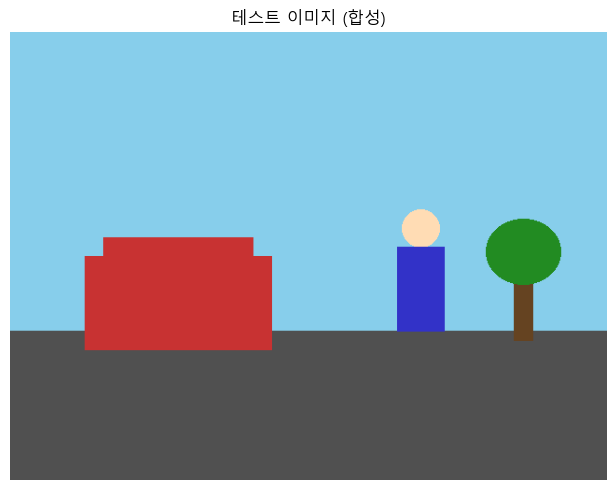

✅ 테스트 이미지 생성 완료


In [2]:
# 테스트 이미지 생성 (외부 다운로드 없이)
from PIL import ImageDraw

IMAGE_DIR.mkdir(parents=True, exist_ok=True)

def make_street_image():
    img = Image.new('RGB', (640, 480), color=(135, 206, 235))  # 하늘
    draw = ImageDraw.Draw(img)
    draw.rectangle([0, 320, 640, 480], fill=(80, 80, 80))      # 도로
    draw.rectangle([80, 240, 280, 340], fill=(200, 50, 50))    # 건물
    draw.rectangle([100, 220, 260, 250], fill=(200, 50, 50))   # 건물 지붕
    draw.ellipse([420, 190, 460, 230], fill=(255, 220, 180))   # 사람 머리
    draw.rectangle([415, 230, 465, 320], fill=(50, 50, 200))   # 사람 몸
    draw.rectangle([540, 260, 560, 330], fill=(101, 67, 33))   # 나무 기둥
    draw.ellipse([510, 200, 590, 270], fill=(34, 139, 34))     # 나무 잎
    return img

street = make_street_image()
street.save(IMAGE_DIR / 'street.jpg', 'JPEG')
street.save(IMAGE_DIR / 'office.jpg', 'JPEG')

plt.figure(figsize=(8, 5))
plt.imshow(street)
plt.title('테스트 이미지 (합성)')
plt.axis('off')
plt.tight_layout()
plt.show()
print('✅ 테스트 이미지 생성 완료')

## 2. 모델 로드 — HuggingFace 네이티브

```python
AutoModelForZeroShotObjectDetection  # transformers 내장
```

- **모델 ID**: `IDEA-Research/grounding-dino-tiny`
- groundingdino-py 패키지 불필요
- 첫 실행 시 HuggingFace Hub에서 자동 다운로드 (~660 MB)

In [3]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

MODEL_ID = 'IDEA-Research/grounding-dino-tiny'

print(f'모델 로드 중: {MODEL_ID}')
print('(첫 실행 시 HuggingFace Hub에서 다운로드, ~660 MB)')

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()

print(f'\n✅ 모델 로드 완료')
print(f'   디바이스: {DEVICE}')
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'   파라미터: {total_params:.1f}M')

모델 로드 중: IDEA-Research/grounding-dino-tiny
(첫 실행 시 HuggingFace Hub에서 다운로드, ~660 MB)


Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]


✅ 모델 로드 완료
   디바이스: cpu
   파라미터: 172.2M


## 3. 추론 함수 정의

프롬프트 형식:
- 단일: `"person."`
- 복수: `"person . car . tree."`  (점으로 구분, 각 단어 뒤에 점)

In [4]:
def detect(image_path, prompt, threshold=0.3):
    """HuggingFace Grounding DINO 추론"""
    image = Image.open(image_path).convert('RGB')
    # 각 단어 뒤에 마침표 보장 (모델 요구 형식)
    fmt = ' . '.join([w.strip().rstrip('.') for w in prompt.split('.') if w.strip()]) + '.'
    inputs = processor(images=image, text=fmt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=threshold,
        text_threshold=threshold,
        target_sizes=[image.size[::-1]]
    )[0]
    return image, results


def visualize(image, results, title=''):
    """바운딩 박스 시각화"""
    fig, ax = plt.subplots(1, figsize=(10, 7))
    ax.imshow(image)

    colors = plt.cm.Set1(np.linspace(0, 1, max(len(results['boxes']), 1)))
    for i, (box, score, label) in enumerate(zip(
        results['boxes'], results['scores'], results['labels']
    )):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=colors[i], facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1 - 5, f'{label} {score:.2f}',
            color='white', fontsize=10, fontweight='bold',
            bbox=dict(facecolor=colors[i], alpha=0.7, pad=2)
        )

    ax.set_title(f'{title}  |  감지: {len(results["boxes"])}개', fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    for i, (box, score, label) in enumerate(zip(
        results['boxes'], results['scores'], results['labels']
    )):
        print(f'  {i+1}. {label:20s} | score: {score:.4f} | box: {[round(v,1) for v in box.tolist()]}')

print('✅ 추론/시각화 함수 정의 완료')

✅ 추론/시각화 함수 정의 완료


## 4. 텍스트 프롬프트 → 바운딩 박스 추출

C:\Users\apple\Desktop\ai_agent_project\.venv\Lib\site-packages\transformers\models\grounding_dino\processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


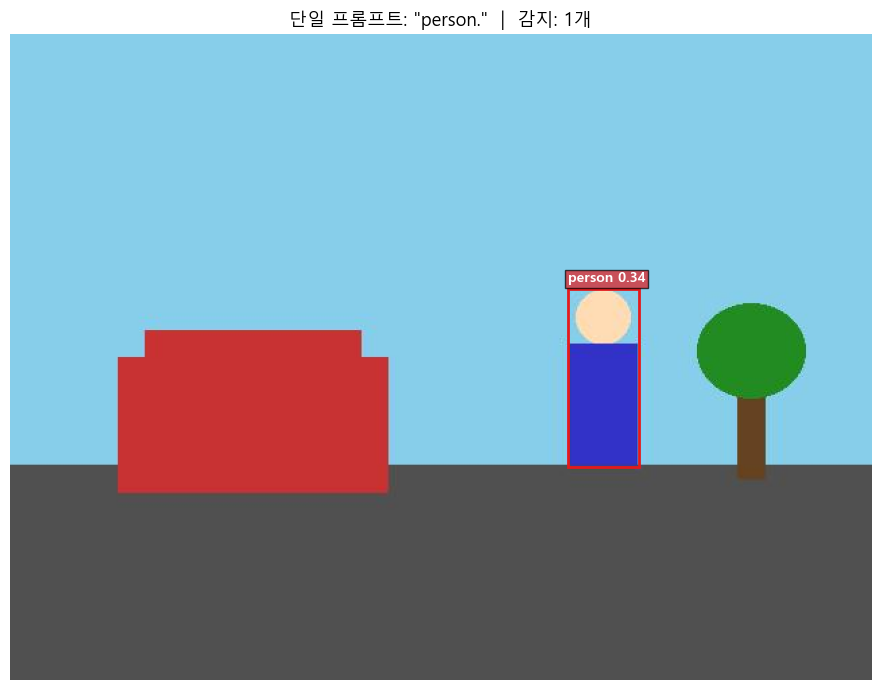

  1. person               | score: 0.3412 | box: [414.1, 189.0, 467.1, 320.8]


In [5]:
# 단일 프롬프트 — person 감지
image, results = detect(IMAGE_DIR / 'street.jpg', 'person.', threshold=0.3)
visualize(image, results, title='단일 프롬프트: "person."')

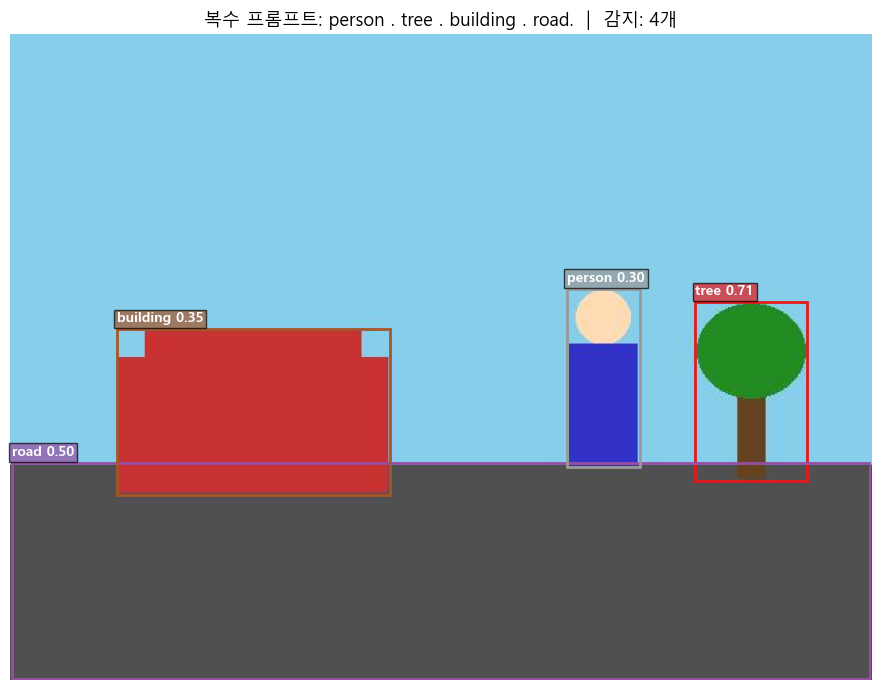

  1. tree                 | score: 0.7130 | box: [508.9, 198.6, 591.7, 331.3]
  2. road                 | score: 0.4986 | box: [0.9, 318.1, 639.0, 478.8]
  3. building             | score: 0.3508 | box: [79.0, 218.7, 282.1, 342.1]
  4. person               | score: 0.2968 | box: [413.7, 188.7, 467.7, 321.0]


In [6]:
# 복수 프롬프트 — 여러 클래스 동시 감지
image, results = detect(
    IMAGE_DIR / 'street.jpg',
    'person . tree . building . road.',
    threshold=0.2
)
visualize(image, results, title='복수 프롬프트: person . tree . building . road.')

## 5. 임계값(Threshold) 튜닝 실험

- `threshold` 낮을수록 → 더 많이 감지 (FP 증가)
- `threshold` 높을수록 → 확실한 것만 감지 (FN 증가)

 threshold  감지 수  평균 score  최고 score
      0.10     8    0.2770    0.7321
      0.15     6    0.3284    0.7321
      0.20     3    0.4782    0.7321
      0.30     3    0.4782    0.7321
      0.40     1    0.7321    0.7321
      0.50     1    0.7321    0.7321


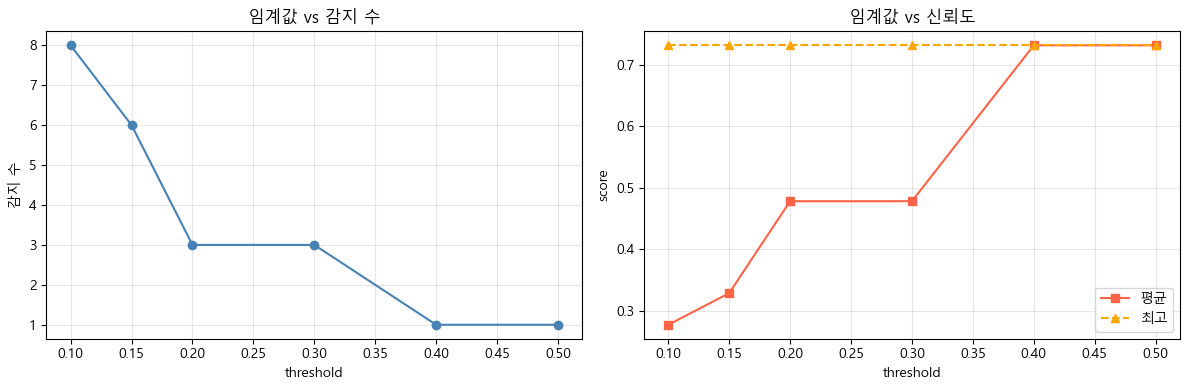

✅ 저장: output/01_threshold_sweep.png


In [7]:
thresholds = [0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
prompt = 'person . tree . building.'
rows = []

for t in thresholds:
    _, res = detect(IMAGE_DIR / 'street.jpg', prompt, threshold=t)
    scores = res['scores'].tolist()
    rows.append({
        'threshold': t,
        '감지 수': len(scores),
        '평균 score': round(np.mean(scores), 4) if scores else 0.0,
        '최고 score': round(max(scores), 4) if scores else 0.0,
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df['threshold'], df['감지 수'], 'o-', color='steelblue')
axes[0].set_xlabel('threshold')
axes[0].set_ylabel('감지 수')
axes[0].set_title('임계값 vs 감지 수')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['threshold'], df['평균 score'], 's-', color='tomato', label='평균')
axes[1].plot(df['threshold'], df['최고 score'], '^--', color='orange', label='최고')
axes[1].set_xlabel('threshold')
axes[1].set_ylabel('score')
axes[1].set_title('임계값 vs 신뢰도')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/01_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: output/01_threshold_sweep.png')

## 6. YOLO vs Grounding DINO 비교

In [8]:
comparison = {
    '항목': ['감지 방식', '클래스 수', '새 클래스 추가', '추론 속도', '정확도 (COCO)', '사용 편의성'],
    'YOLOv8': [
        '학습된 클래스 분류',
        '80개 고정',
        '재학습 필요',
        '빠름 (~50ms)',
        'mAP 53.9',
        '높음 (설정 간단)',
    ],
    'Grounding DINO': [
        '텍스트-이미지 정렬',
        '무제한 (자연어)',
        '프롬프트만 수정',
        '느림 (~300ms CPU)',
        'AP 48.4 (제로샷)',
        '높음 (프롬프트 작성)',
    ],
}

df_cmp = pd.DataFrame(comparison).set_index('항목')
print('=== YOLO vs Grounding DINO ===')
print(df_cmp.to_string())

print('\n[결론]')
print('- 속도 우선, 고정 클래스 환경  → YOLOv8')
print('- 유연성 우선, 새로운 도메인    → Grounding DINO')
print('- 최선의 결합: DINO로 탐색 → YOLO로 특화 학습')

=== YOLO vs Grounding DINO ===
                YOLOv8   Grounding DINO
항목                                     
감지 방식       학습된 클래스 분류       텍스트-이미지 정렬
클래스 수           80개 고정        무제한 (자연어)
새 클래스 추가        재학습 필요         프롬프트만 수정
추론 속도       빠름 (~50ms)  느림 (~300ms CPU)
정확도 (COCO)    mAP 53.9    AP 48.4 (제로샷)
사용 편의성      높음 (설정 간단)     높음 (프롬프트 작성)

[결론]
- 속도 우선, 고정 클래스 환경  → YOLOv8
- 유연성 우선, 새로운 도메인    → Grounding DINO
- 최선의 결합: DINO로 탐색 → YOLO로 특화 학습


## 7. 속도 벤치마크

추론 속도 (n=10, device=cpu)
  평균: 3577.0 ms
  최소: 3441.0 ms
  최대: 3776.3 ms
  FPS:  0.3


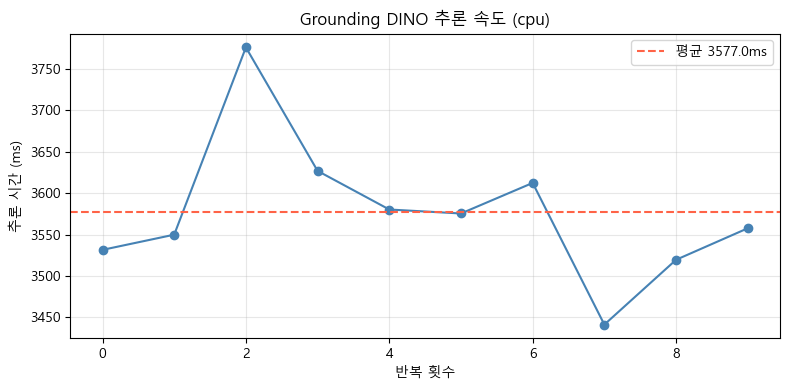

✅ 저장: output/01_speed_benchmark.png


In [9]:
N = 10
prompt = 'person . tree . building.'

# 워밍업
detect(IMAGE_DIR / 'street.jpg', prompt, threshold=0.3)

times = []
for _ in range(N):
    t0 = time.time()
    detect(IMAGE_DIR / 'street.jpg', prompt, threshold=0.3)
    times.append((time.time() - t0) * 1000)

avg_ms = sum(times) / len(times)
print(f'추론 속도 (n={N}, device={DEVICE})')
print(f'  평균: {avg_ms:.1f} ms')
print(f'  최소: {min(times):.1f} ms')
print(f'  최대: {max(times):.1f} ms')
print(f'  FPS:  {1000/avg_ms:.1f}')

plt.figure(figsize=(8, 4))
plt.plot(times, 'o-', color='steelblue')
plt.axhline(avg_ms, color='tomato', linestyle='--', label=f'평균 {avg_ms:.1f}ms')
plt.xlabel('반복 횟수')
plt.ylabel('추론 시간 (ms)')
plt.title(f'Grounding DINO 추론 속도 ({DEVICE})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/01_speed_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: output/01_speed_benchmark.png')

In [10]:
print('=' * 52)
print('Notebook 01 — Grounding DINO 기초 완료')
print('=' * 52)
print()
print('[학습한 것]')
print('  1. HuggingFace AutoModelForZeroShotObjectDetection')
print('  2. 텍스트 프롬프트로 임의 객체 제로샷 감지')
print('  3. threshold 튜닝 — 감지 수 vs 정확도 트레이드오프')
print('  4. YOLO(속도) vs DINO(유연성) 비교')
print()
print('[저장된 결과물]')
print('  - output/01_threshold_sweep.png')
print('  - output/01_speed_benchmark.png')
print()
print('[다음 노트북]')
print('  02_sam2_integration.ipynb')
print('  → DINO 박스를 SAM2 프롬프트로 연결, 픽셀 마스크 생성')

Notebook 01 — Grounding DINO 기초 완료

[학습한 것]
  1. HuggingFace AutoModelForZeroShotObjectDetection
  2. 텍스트 프롬프트로 임의 객체 제로샷 감지
  3. threshold 튜닝 — 감지 수 vs 정확도 트레이드오프
  4. YOLO(속도) vs DINO(유연성) 비교

[저장된 결과물]
  - output/01_threshold_sweep.png
  - output/01_speed_benchmark.png

[다음 노트북]
  02_sam2_integration.ipynb
  → DINO 박스를 SAM2 프롬프트로 연결, 픽셀 마스크 생성
